# Exploratory Data Analysis (EDA)

## 0. Loading in Data

In [1]:
from pathlib import Path

import pandas as pd

# Relative to repository root (same layout as scripts/build_merged_ed_dataframe.py output)
MERGED_RELATIVE = Path("data") / "processed" / "merged_ed_dataframe.pkl"


def repo_root() -> Path:
    """Find project root by walking up from cwd until `config.yaml` exists."""
    start = Path.cwd().resolve()
    for directory in (start, *start.parents):
        if (directory / "config.yaml").is_file():
            return directory
    raise FileNotFoundError(
        "Could not find project root (no config.yaml in cwd or parents). "
        "Run the notebook with the working directory inside the repo."
    )


ROOT = repo_root()
merged_path = ROOT / MERGED_RELATIVE

if not merged_path.is_file():
    raise FileNotFoundError(
        f"Missing {merged_path}. Generate it with: "
        f"python scripts/build_merged_ed_dataframe.py --output {MERGED_RELATIVE.as_posix()}"
    )

df = pd.read_pickle(merged_path)
print(f"Loaded {len(df):,} rows × {df.shape[1]} cols from {merged_path.relative_to(ROOT)}")

Loaded 128,076 rows × 1059 cols from data/processed/merged_ed_dataframe.pkl


## 1. Data Summary

In [2]:
df.head()

,VMONTH,VDAYR,ARRTIME,WAITTIME,LOV,AGE,AGER,AGEDAYS,RESIDNCE,SEX,...,PTONLINEE2,PTONLINEE3,PTONLINEE4,PTONLINEE5,PTONLINEE6,BLANK1,BLANK2,BLANK3,BLANK4,COVID_VALIDATION
0,11.0,2.0,1236,18.0,210.0,26.0,3.0,-7.0,1.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,11.0,2.0,2114,103.0,247.0,53.0,4.0,-7.0,1.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,11.0,3.0,1619,73.0,174.0,45.0,4.0,-7.0,1.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,11.0,4.0,0950,27.0,94.0,40.0,3.0,-7.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,11.0,4.0,1738,1.0,150.0,35.0,3.0,-7.0,1.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128076 entries, 0 to 128075
Columns: 1059 entries, VMONTH to COVID_VALIDATION
dtypes: float64(492), object(567)
memory usage: 1.0+ GB


In [7]:
df.duplicated().sum()

0

## 2. Variable Distributions

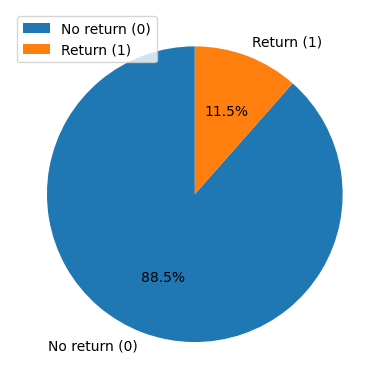

In [5]:
import matplotlib.pyplot as plt

counts = df["RETRNED"].value_counts()
plt.pie(counts, labels=["No return (0)", "Return (1)"], autopct="%1.1f%%", startangle=90)
plt.legend()
plt.show()

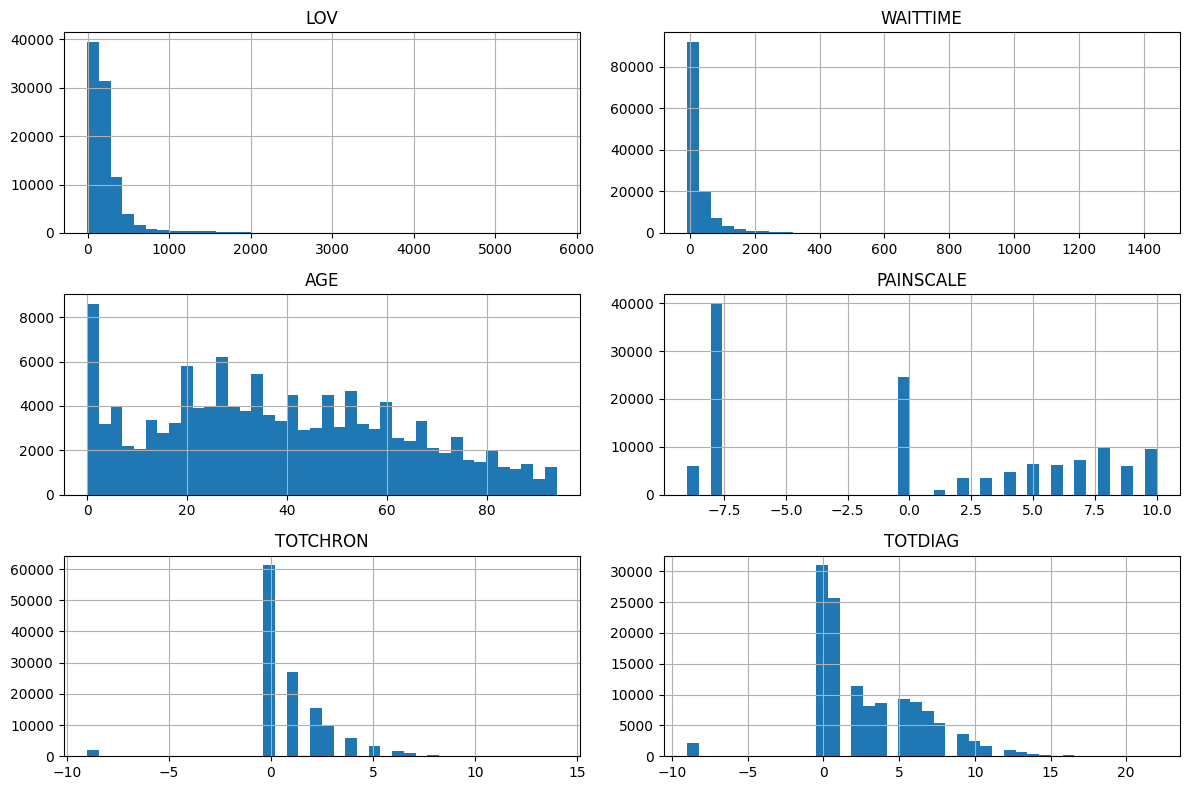

In [6]:
df[["LOV", "WAITTIME", "AGE", "PAINSCALE", "TOTCHRON", "TOTDIAG"]].hist(bins=40, figsize=(12, 8))
plt.tight_layout()
plt.show()